Approximate maximum at point: (-2.1183944462046265, 0.17444352311533173) with value: 13.48743015241354
Algorithm converged at point: (-2.178507764864141, -0.13886213048269444) with value: 13.357156412225653


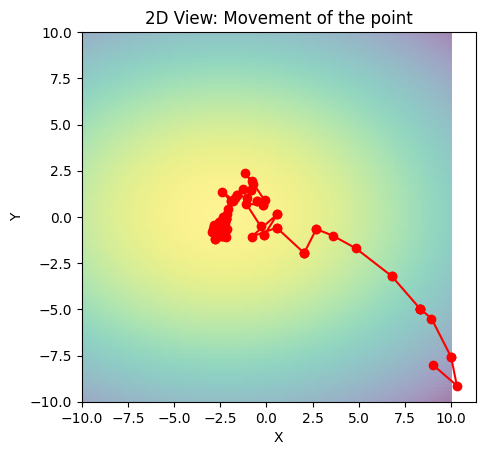

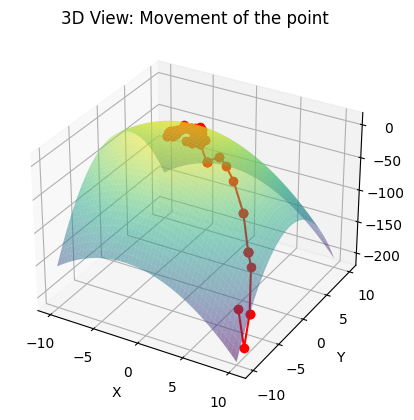

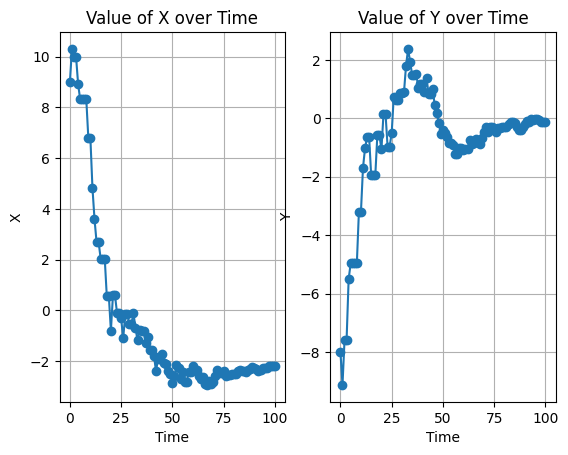

In [233]:
# 1. Import Relevant Libraries
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 2. Declare Constants and Variables
start_x = 9
start_y = -8

max_iter = 100
step_size = 3
initial_temp = 8
cooling_rate = 0.965
min_temp = 0.08

# 3. Function to Define Surface
def f(x, y):
    return -0.65 * x ** 2 - 3 * x - 1.25 * y ** 2 + 0.5 * y + 10

# 4. Initialization

current_solution = (start_x, start_y)
current_value = f(start_x, start_y)

best_solution = current_solution
best_value = current_value

temperature = initial_temp
current_step_size = step_size

x_path = [start_x]
y_path = [start_y]

x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

# 5. Main Loop

for iteration in range(max_iter):
    
    delta_x = random.uniform(-1, 1) * current_step_size
    delta_y = random.uniform(-1, 1) * current_step_size

    neighbor_solution = (current_solution[0] + delta_x, current_solution[1] + delta_y)
    neighbor_value = f(neighbor_solution[0], neighbor_solution[1])

    delta_e = neighbor_value - current_value
    #if delta_e < 0:
    #    print(delta_e, temperature, math.exp(delta_e / temperature) )

    if delta_e > 0 or random.uniform(0, 1) < math.exp(delta_e / temperature):
        current_solution = neighbor_solution
        current_value = neighbor_value

        if current_value > best_value:
            best_solution = current_solution
            best_value = current_value

    x_path.append(current_solution[0])
    y_path.append(current_solution[1])
    temperature *= cooling_rate
    current_step_size = current_step_size * cooling_rate

    if temperature < min_temp:
        temperature = min_temp

# 6. Visualize Results
print(f"Approximate maximum at point: {best_solution} with value: {best_value}")
print(f"Algorithm converged at point: {current_solution} with value: {current_value}")

# 2D Visualization
plt.figure()
plt.imshow(Z, extent=[-10, 10, -10, 10], origin='lower', cmap='viridis', alpha=0.5)
plt.plot(x_path, y_path, 'r-o')
plt.title("2D View: Movement of the point")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# 3D Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
z_path = [f(x, y) for x, y in zip(x_path, y_path)]
ax.plot(x_path, y_path, z_path, 'r-o')
ax.set_title("3D View: Movement of the point")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

# Plot x and y vs time
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(x_path, '-o')
ax1.set_title("Value of X over Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("X")
ax1.grid(True)

ax2.plot(y_path, '-o')
ax2.set_title("Value of Y over Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Y")
ax2.grid(True)

plt.show()
